In [25]:
# load necessary libraries
import json
import pandas as pd
import re
import sys
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import umap

# set path to project root
base_path = Path.cwd() / "../"
sys.path.append(str(base_path.resolve()))

# load the dictionary terms
groups_dictionary = pd.read_csv("../01_data/dictionary/groups_dictionary.csv")

# load the ground truth data with augmentations
with open("../01_data/annotations/annotations_augmentations.json") as f:
    gt_augmentations = json.load(f)

In [26]:
def regex_pattern_colmatch(dictionary_df, column):
    # get all patterns in the dictionary to look for
    patterns = [word for word in dictionary_df[column] if pd.notna(word)]

    # initialize empty list to store the regex pattern
    regex_patterns = []

    # loop through all patterns
    for pat in patterns:

        # split pattern into words by spaces
        tokens = pat.split()
        regex_parts = []

        # loop through all tokens of the pattern
        for token in tokens:

            # match any word if asterisk is a separate token
            if token == '*':
                regex_parts.append(r'\w+')
            
            # match any prefix to the word
            elif token.startswith('*') and len(token) > 1:
                word = token[1:]
                regex_parts.append(rf'\w*{re.escape(word)}')
            
            # match any suffix to the word
            elif token.endswith('*') and len(token) > 1:
                word = token[:-1]
                regex_parts.append(rf'{re.escape(word)}\w*')

            # if no asterisk, take the word as is
            else:
                regex_parts.append(re.escape(token))

        # join tokens with \s+ to match spaces and append to the list of patterns
        regex_pattern = r'\b' + r'\s+'.join(regex_parts) + r'\b'
        regex_patterns.append(regex_pattern)

    # combine all regex patterns to one with or condition
    combined_regex = "|".join(regex_patterns)

    return combined_regex

In [29]:
# keep only texts with social groups and separate to have one sample per social group
filtered_gt = []
for sent in gt_augmentations:
    if sent["annotations"]:
        for ann in sent["annotations"]:
            filtered_gt.append(
                {
                    "sentence": sent["sentence"],
                    "group": ann["text"]
                }
            )

# find exact dictionary matches for the group annotations
sentence_list = []
mention_list = []
category_list = []
categories = groups_dictionary.columns
cat2id = {c: i for i, c in enumerate(categories)}
for cat in categories:
    regex_pattern = regex_pattern_colmatch(groups_dictionary, cat)
    compiled = re.compile(regex_pattern)
    for sent in filtered_gt:
        if compiled.fullmatch(sent["group"]):
            sentence_list.append(sent["sentence"])
            mention_list.append(sent["group"])
            category_list.append(cat)

In [55]:
class SpanDataset(Dataset):
    def __init__(self, tokenizer, cat2id, sentences, mentions, labels, max_len=64):
        self.tokenizer = tokenizer
        self.cat2id = cat2id
        self.sentences = sentences
        self.mentions = mentions
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        mention = self.mentions[idx]
        label = self.labels[idx]

        # tokenize the full sentence
        encoding = self.tokenizer(
            sentence,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_offsets_mapping=True,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        offsets = encoding["offset_mapping"].squeeze(0)

        # find token indices for the first match
        start_char = sentence.find(mention)
        end_char = start_char + len(mention)
        token_indices = [
            i for i, (s, e) in enumerate(offsets.tolist())
            if s >= start_char and e <= end_char
        ]

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "token_indices": torch.tensor(token_indices, dtype=torch.long),
            "label_id": torch.tensor(self.cat2id[label], dtype=torch.long)
        }

In [56]:
def collate_fn(batch):
    input_ids = torch.stack([x["input_ids"] for x in batch])
    attention_mask = torch.stack([x["attention_mask"] for x in batch])
    labels = torch.tensor([x["label_id"] for x in batch])
    token_indices_list = [x["token_indices"] for x in batch]

    return input_ids, attention_mask, token_indices_list, labels

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
dataset = SpanDataset(tokenizer, cat2id, sentence_list, mention_list, category_list)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn, drop_last=True)

In [81]:
class SpanEncoder(nn.Module):
    def __init__(self, model_name="roberta-base", proj_dim=128):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, proj_dim)
        )

    def forward(self, input_ids, attention_mask, token_indices_list):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        # Pool embeddings over each span
        pooled_embeddings = []
        for i, token_indices in enumerate(token_indices_list):
            tokens = last_hidden[i, token_indices, :]
            pooled = tokens.mean(dim=0)  # mean pooling
            pooled_embeddings.append(pooled)
        h = torch.stack(pooled_embeddings)  # (batch_size, hidden_size)

        z = self.projector(h)  # projection head
        return h, z


def supervised_contrastive_loss(embeddings, labels, temperature=0.1):
    embeddings = F.normalize(embeddings, dim=1)
    sim_matrix = torch.matmul(embeddings, embeddings.T) / temperature

    labels = labels.unsqueeze(1)
    
    mask = torch.eq(labels, labels.T).float()
    mask.fill_diagonal_(0)

    pos_counts = mask.sum(1)
    valid = pos_counts > 0
    pos_counts = torch.clamp(pos_counts, min=1)

    log_prob = F.log_softmax(sim_matrix, dim=1)
    mean_log_prob_pos = (mask * log_prob).sum(1) / pos_counts
    loss = -mean_log_prob_pos[valid].mean()
    return loss

In [82]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = SpanEncoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

for epoch in range(10):

    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Trainig")

    for input_ids, attention_mask, token_indices_list, labels in progress_bar:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        print(labels)
        token_indices_list = [t.to(device) for t in token_indices_list]
        
        # clear the old gradient
        optimizer.zero_grad()

        # run data through the model and save the outputs, use mps with mixed precision (16 bit floating point for forward pass)
        _, z = model(input_ids, attention_mask, token_indices_list)
        # calculate the loss and add to total loss
        loss = supervised_contrastive_loss(z, labels)
        total_loss += loss.item()

        # run backpropagation, cap gradients to prevent explosion
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)

        # update parameters and the progress bar
        optimizer.step()
        progress_bar.set_postfix(loss=loss.item())

    # calculate average batch loss and print it
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}, Average Batch Loss: {avg_loss:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Trainig:   0%|          | 0/22 [00:00<?, ?it/s]

tensor([10, 43, 36,  5,  7, 35, 24, 14, 43, 19,  2, 43, 12,  2, 19,  2, 40, 12,
        10, 44, 29, 12, 28, 13, 33,  9,  3,  5,  2,  6, 36, 44, 10, 21,  8,  5,
        38, 12, 36, 26, 36, 10, 35, 19, 28, 13,  5, 12, 12, 12, 44,  5, 36,  2,
        13, 38,  6, 30, 44,  6,  2, 37, 44,  2], device='mps:0')


Trainig:   0%|          | 0/22 [00:01<?, ?it/s]


RuntimeError: MPS backend out of memory (MPS allocated: 17.54 GB, other allocations: 611.55 MB, max allowed: 18.13 GB). Tried to allocate 12.00 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

In [19]:
model.eval()

with torch.no_grad():
    all_embeddings = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        batch_labels = batch["label_id"].to(device)
        h, z = model(input_ids, attention_mask)
        all_embeddings.append(z.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
labels_np = np.array([cat2id[cat] for cat in category_list])

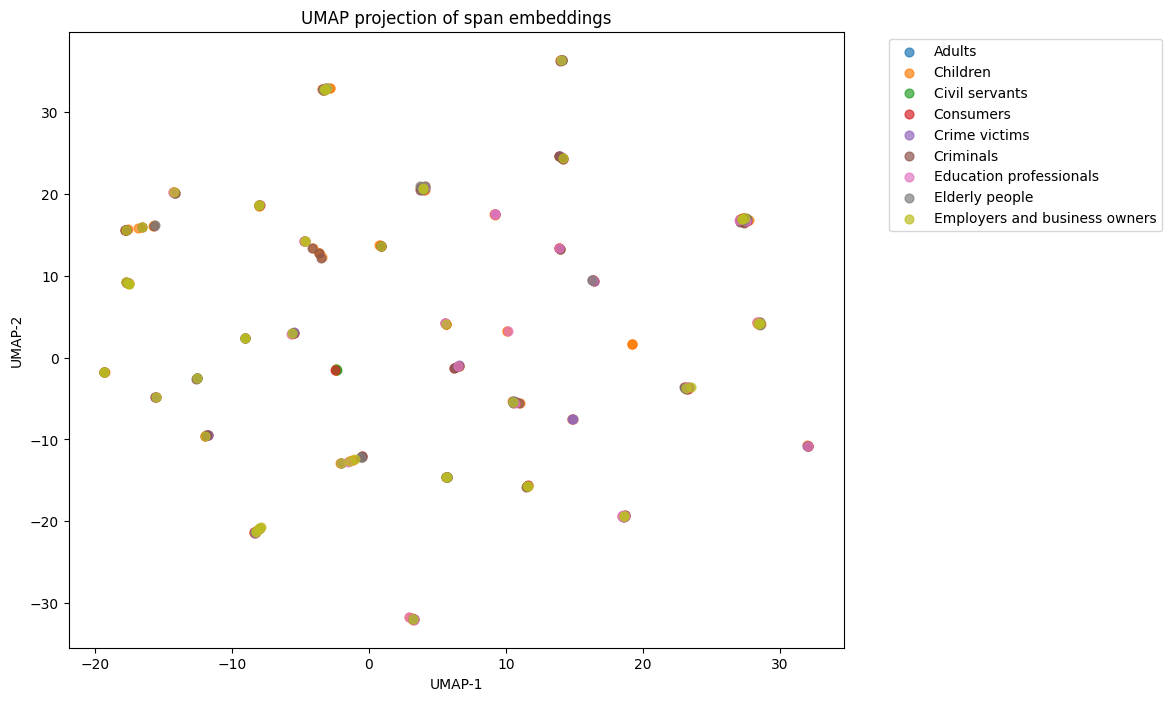

In [20]:
reducer = umap.UMAP(
    n_neighbors=15,   # controls local vs global structure
    min_dist=0.1,     # how tightly points are packed
    metric="cosine"   # best for embeddings
)

# Fit and transform
embedding_2d = reducer.fit_transform(all_embeddings)

plt.figure(figsize=(10, 8))
categories = list(cat2id.keys())
num_classes = len(categories)

for c in range(10):
    idx = np.where(labels_np == c)[0]
    if len(idx) == 0:
        continue
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        label=categories[c],
        alpha=0.7,
        s=40
    )

plt.title("UMAP projection of span embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [23]:
dbscan = DBSCAN(eps=.1, min_samples=2, metric='cosine') 
labels = dbscan.fit_predict(all_embeddings)

cluster_dict = defaultdict(list)

for mention, label in zip(mention_list, labels):
    cluster_dict[label].append(mention)

for cluster_id, mentions in cluster_dict.items():
    print(f"Cluster {cluster_id} ({len(mentions)} mentions):")
    for mention in mentions:
        print(f"  - {mention}")
    print()

Cluster 0 (49 mentions):
  - adults
  - child
  - child
  - child
  - children
  - children
  - child
  - children
  - children
  - children
  - child
  - children
  - civil servants
  - civil servants
  - consumers
  - victims
  - victims
  - offenders
  - prisoners
  - older people
  - pensioners
  - older people
  - employers
  - employer
  - workers
  - workers
  - families
  - lone parents
  - the parents
  - farmers
  - GPs
  - police officers
  - veterans
  - people with disabilities
  - engineers
  - learners
  - student
  - students
  - pupils
  - students
  - tenants
  - business people
  - young people
  - young people
  - under-45s
  - young people
  - young people
  - young people
  - young people

Cluster 1 (86 mentions):
  - adults
  - children
  - child
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - children
  - child
  - consumers
  - victims
  